# 03 - Explainability and business risk

Severity drives triage (close vs investigate). This notebook shows what the model uses, how a single case is explained, and the main risks.

Most tables come from `reports/`. Ordered-logit coefficients are computed here.


In [1]:
import json, warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display, Markdown

from severity_triage.config import load_settings
from severity_triage.pipeline import load_bundle
from severity_triage.models import make_pipeline, MODEL_REGISTRY

pd.set_option("display.max_columns", 40); pd.set_option("display.width", 180); pd.set_option("display.precision", 4)
settings = load_settings()
R, F, TAG = settings.paths.reports_dir, settings.paths.figures_dir, settings.regime_tag
def table(name, index_col=None, **kw):
    return pd.read_csv(R / name, index_col=index_col, keep_default_na=False, na_values=[""], **kw)
def fig(name, width=900):
    p = F / name
    if p.exists(): display(Image(filename=str(p), width=width))
    else: print("(figure not produced for this model type:", name, ")")

manifest = json.load(open(settings.paths.models_dir / "run_manifest.json"))
selection = json.load(open(settings.paths.models_dir / f"selection_{TAG}.json"))
family = selection["family"]
print("Selected model:", MODEL_REGISTRY[family].label, "| threshold", manifest["decision"]["threshold"], "at FN:FP", manifest["decision"]["cost_ratio"])

Selected model: Proportional-odds (ordered) logit | threshold 0.19 at FN:FP 5.0


## 1. Permutation importance

Shuffle one feature at a time and measure the drop in QWK.


,feature,importance_mean,importance_std,rank
0,EstimatedRiskScore,0.2421,0.0126,1
1,impact_risk_gap,0.0661,0.0052,2
2,EstimatedImpactScore,0.0360,0.0041,3
3,log_ExpectedFinancialRedressGBP,0.0296,0.0037,4
4,EmotionalImpactLevel_code,0.0084,0.0037,5
5,log_RecoveryTimeMonths,0.0062,0.0022,6
6,log_DurationAffectedDays,0.0053,0.0033,7
7,PredictedRemedyBand_code,0.0035,0.0015,8
8,ExpectedFinancialRedressGBP,0.0030,0.0015,9
9,impact_risk_mean,0.0021,0.0016,10


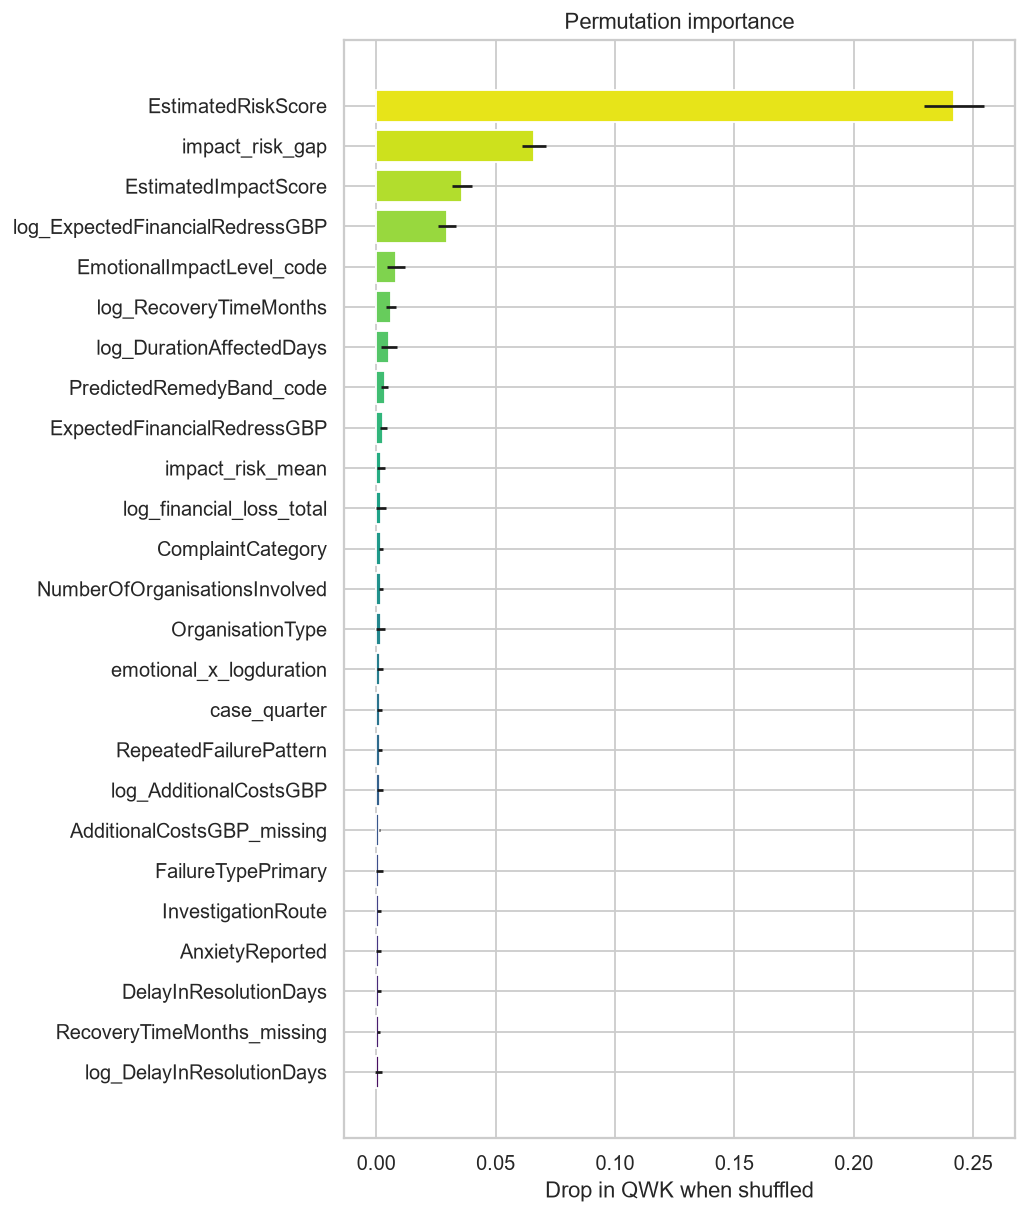

Features with negligible importance (<0.001): 58 of 82


In [2]:
perm = table(f"permutation_importance_{TAG}.csv")
display(perm.head(15).round(4))
fig(f"permutation_importance_{TAG}.png", 700)
print("Features with negligible importance (<0.001):", int((perm["importance_mean"] < 0.001).sum()), "of", len(perm))

Internal impact and risk scores matter most, then redress and emotional impact. `InvestigationRoute` sits near the bottom, as expected.


## 2. SHAP (expected severity)

Show direction and size of each feature's effect on expected severity.


,feature,mean_abs_shap_severity
0,EstimatedRiskScore,0.589
1,impact_risk_gap,0.288
2,EstimatedImpactScore,0.211
3,log_ExpectedFinancialRedressGBP,0.181
4,EmotionalImpactLevel_code,0.079
5,log_DurationAffectedDays,0.077
6,PredictedRemedyBand_code,0.063
7,log_RecoveryTimeMonths,0.058
8,log_financial_loss_total,0.043
9,EstimatedImpactScore_missing,0.034


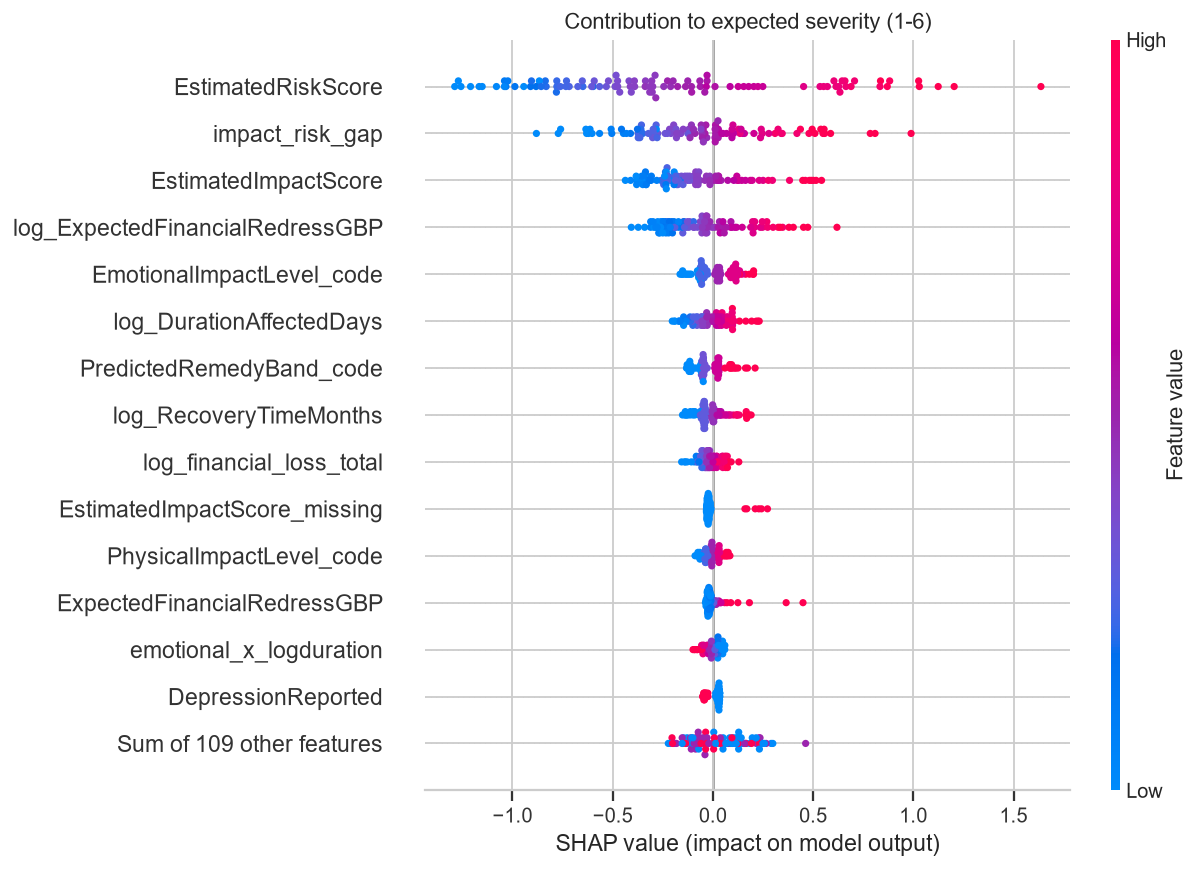

In [3]:
display(table(f"shap_expected_severity_{TAG}.csv").head(15).round(3))
fig(f"shap_expected_severity_beeswarm_{TAG}.png", 800)

Higher impact, risk, redress and duration push severity up. The gap between impact and risk also matters.


In [4]:
# Exact per-class SHAP is only available for tree boosters; shown when the selected model is one.
for cls in (1, 6):
    fig(f"shap_beeswarm_class{cls}_{TAG}.png", 700)

(figure not produced for this model type: shap_beeswarm_class1_regime_a.png )
(figure not produced for this model type: shap_beeswarm_class6_regime_a.png )


## 3. Three example cases

One clear close, one clear investigate, and one near the threshold.


,case_type,CaseReference,true_severity,predicted_argmax,p_severe,expected_severity
0,clearly_not_severe,TRN-001782,1,1,0.000,1.000
1,clearly_severe,TRN-001862,6,6,1.000,6.000
2,borderline,TRN-000221,3,3,0.171,3.164


**Clearly Not Severe**

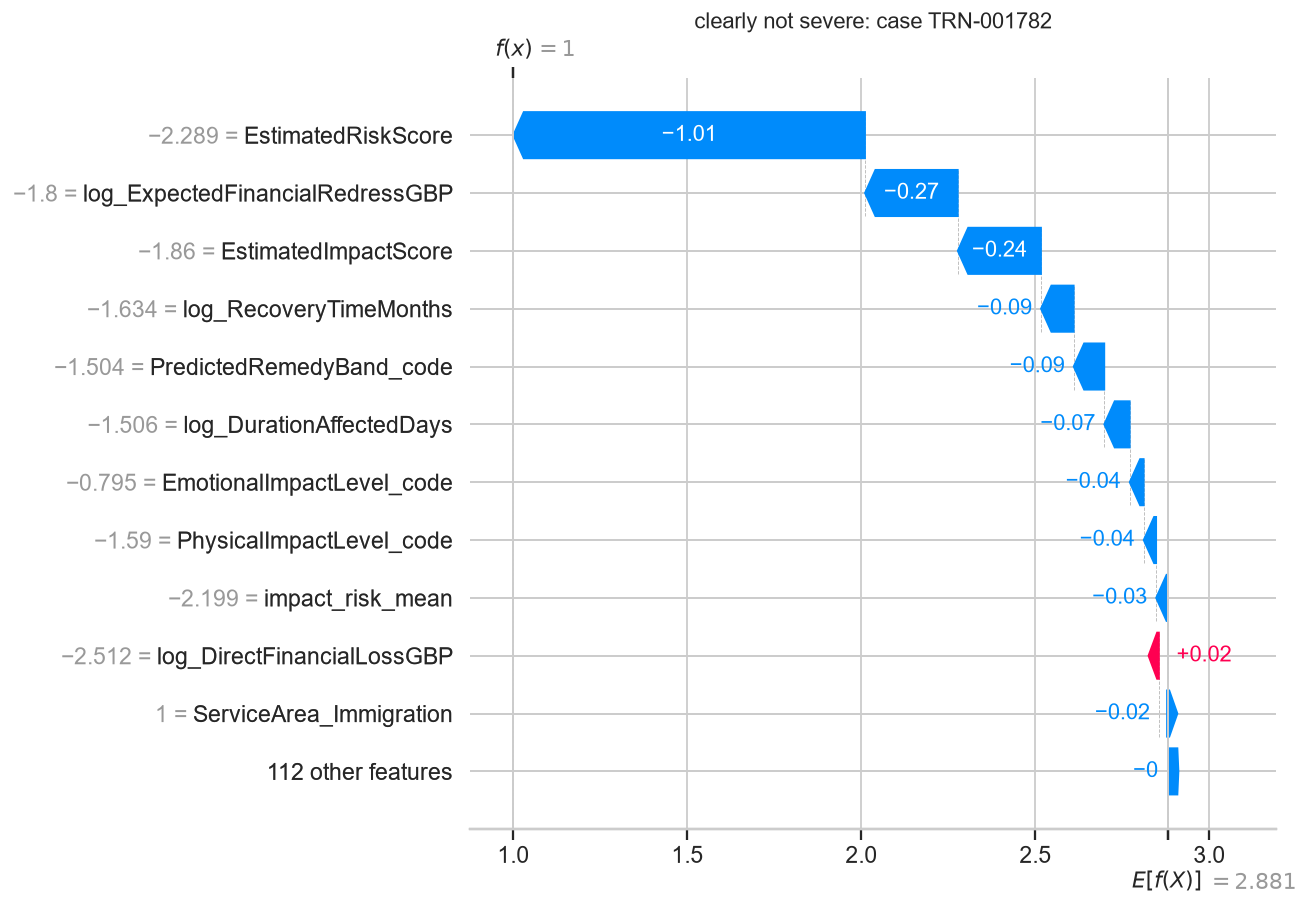

**Borderline**

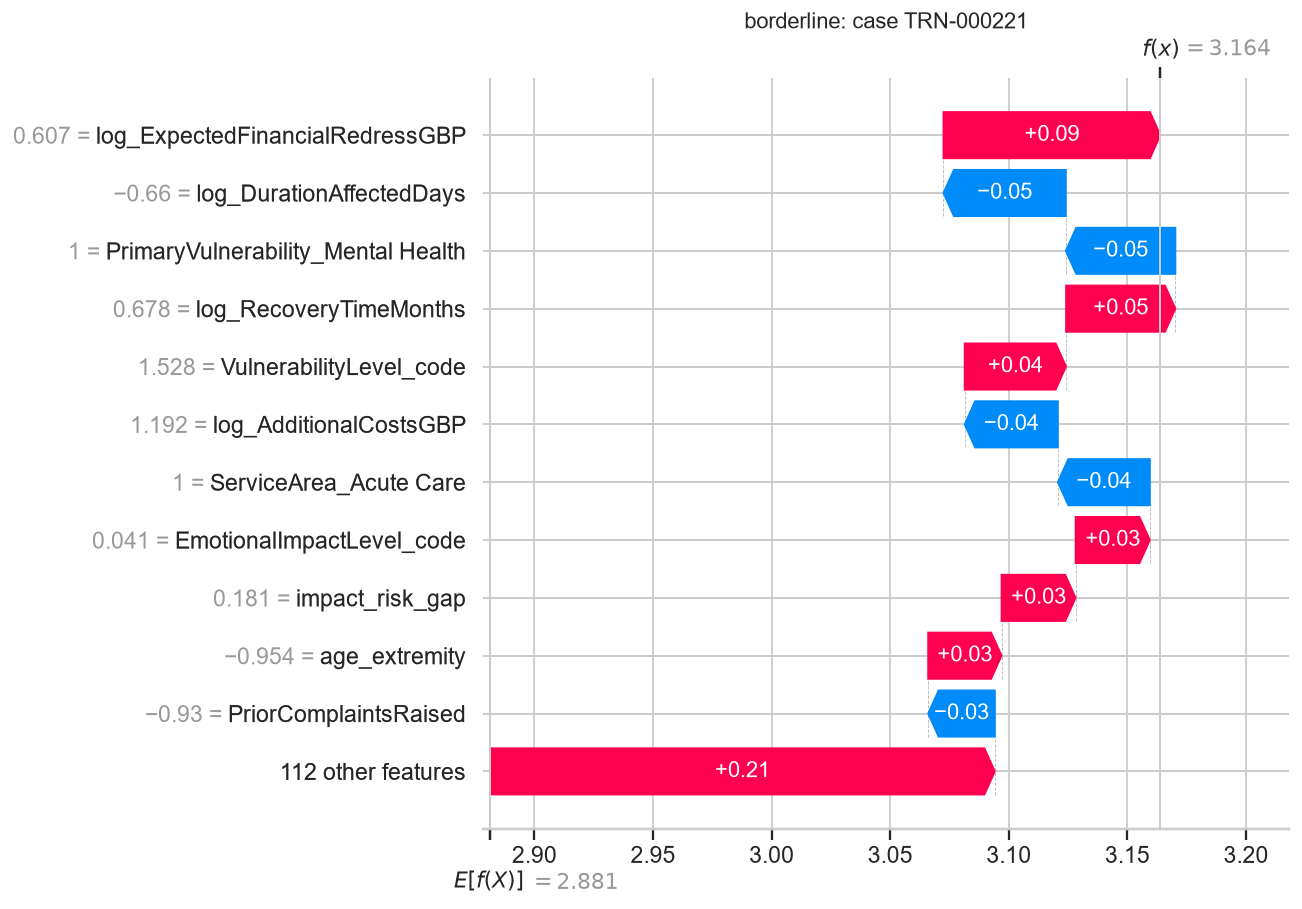

**Clearly Severe**

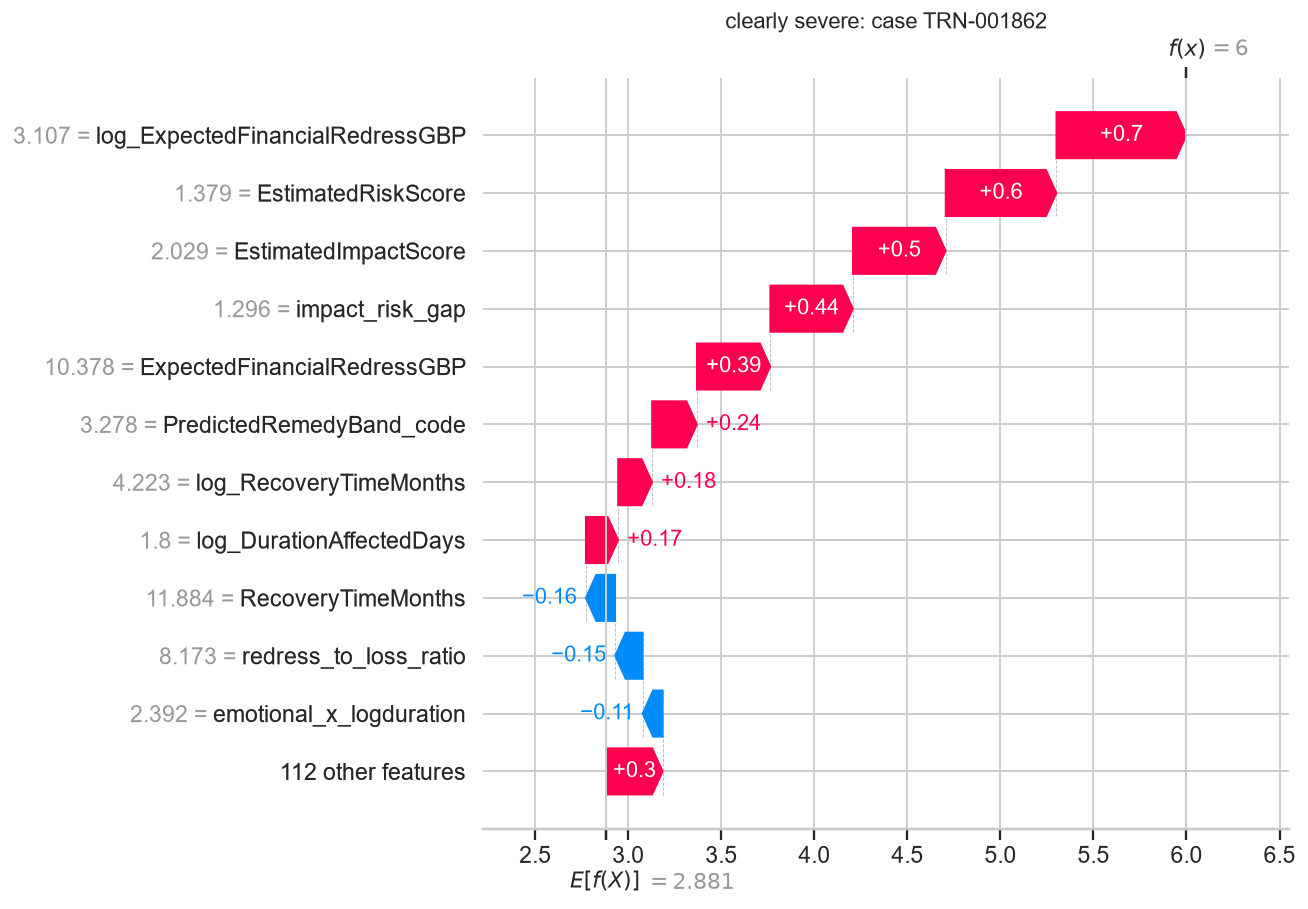

In [5]:
display(table(f"illustrative_cases_{TAG}.csv").round(3))
for label in ("clearly_not_severe", "borderline", "clearly_severe"):
    display(Markdown(f"**{label.replace('_', ' ').title()}**"))
    fig(f"shap_waterfall_{label}_{TAG}.png", 700)

The borderline case is the operational one: a small input change can flip close vs investigate. Those cases should stay with a human.


## 4. Ordered logit structure

One latent score and five cut-points. Easy to read.


In [6]:
bundle = load_bundle(settings)
train_idx, test_idx = bundle.split(settings)
ordered = make_pipeline("ordered_logit", bundle.spec, settings.project.seed).fit(bundle.X.loc[train_idx], bundle.y.loc[train_idx].to_numpy())
clf = ordered.named_steps["clf"]
names = list(ordered.named_steps["pre"].get_feature_names_out())
coef = pd.Series(clf.coef_, index=names).sort_values()
print("Cut-points (latent units):", np.round(clf.cutpoints_, 2))
print("Converged:", clf.converged_, "| iterations:", clf.n_iter_)

fig_, ax = plt.subplots(figsize=(8, 7))
top = pd.concat([coef.head(10), coef.tail(15)])
top.plot.barh(ax=ax, color=["#c44e52" if v < 0 else "#4c72b0" for v in top])
ax.set_title("Ordered logit coefficients (standardised features)"); ax.set_xlabel("effect on latent severity per 1 SD")
plt.show()

Cut-points (latent units): [-8.14 -1.47  4.99 11.58 18.45]
Converged: True | iterations: 303


Largest coefficients are on the internal scores, then redress and emotional impact. Signs match the domain (higher impact → higher severity).


,severity,n,latent_mean,latent_p5,latent_p95
0,1,403,-11.80,-16.66,-7.40
1,2,393,-4.58,-8.89,0.18
2,3,323,1.65,-2.66,5.91
3,4,238,8.27,4.27,12.42
4,5,162,14.89,10.39,18.61
5,6,81,21.60,18.44,25.09


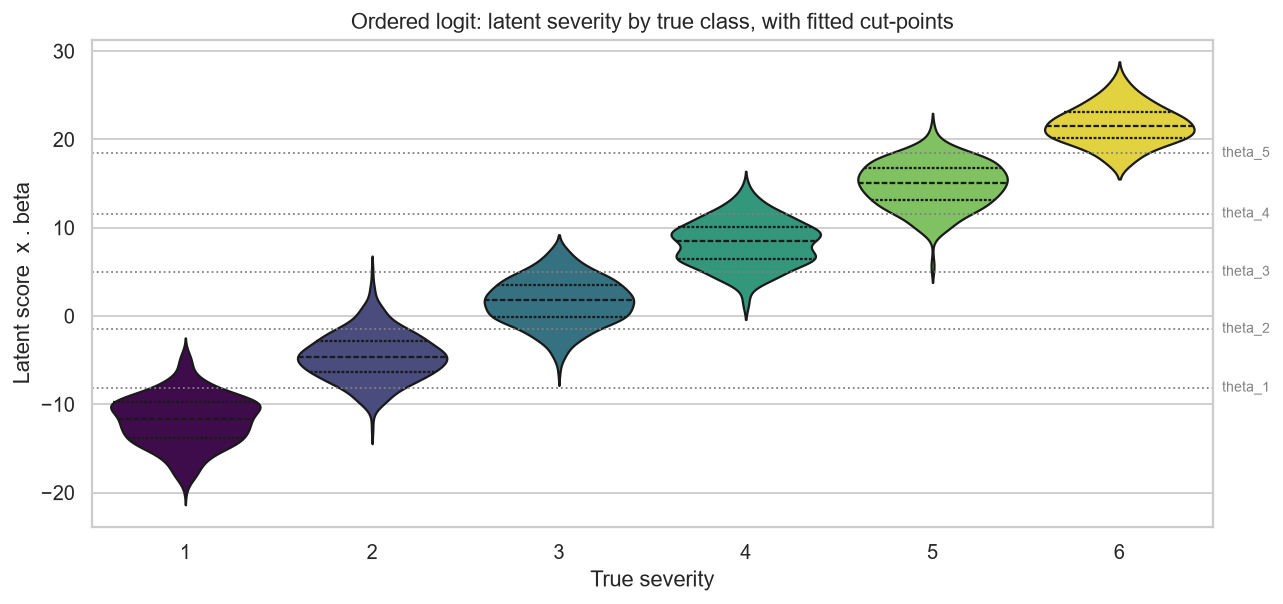

In [7]:
display(table(f"latent_per_class_{TAG}.csv").round(2))
fig(f"latent_scores_{TAG}.png", 900)

### 4a. Severity boundaries from EIS

Fit a simple ordered logit on `EstimatedImpactScore` alone and recover approximate cut points.


In [8]:
eis = table(f"latent_eis_boundaries_{TAG}.csv")
display(eis.round(1))
bounds = eis["recovered_upper_boundary"].dropna().to_numpy()
print("Recovered boundaries:", np.round(bounds, 1), "| spacing:", np.round(np.diff(bounds), 1))

,severity,eis_min,eis_p5,eis_median,eis_p95,eis_max,recovered_upper_boundary
0,1,1,8,23,37.0,44,30.8
1,2,16,26,38,52.0,72,47.5
2,3,30,42,55,67.0,76,64.0
3,4,52,57,70,83.3,89,80.2
4,5,67,73,87,100.0,100,96.3
5,6,82,92,100,100.0,100,NaN


Recovered boundaries: [30.8 47.5 64.  80.2 96.3] | spacing: [16.7 16.5 16.2 16.1]


Cuts fall at roughly even steps (~16 points). That helps explain why a linear ordinal model works well here.


## 5. Simple surrogate rules

A small decision tree that copies the model's triage calls.


In [9]:
print(open(R / f"surrogate_rules_{TAG}.txt", encoding="utf-8").read())

Fidelity to model decisions: 0.966

|--- impact_risk_mean <= 57.2
|   |--- EstimatedImpactScore <= 55.5
|   |   |--- ExpectedFinancialRedressGBP <= 2105.3
|   |   |   |--- -> CLOSE (not progressed)
|   |   |--- ExpectedFinancialRedressGBP >  2105.3
|   |   |   |--- -> CLOSE (not progressed)
|   |--- EstimatedImpactScore >  55.5
|   |   |--- ExpectedFinancialRedressGBP <= 874.0
|   |   |   |--- -> CLOSE (not progressed)
|   |   |--- ExpectedFinancialRedressGBP >  874.0
|   |   |   |--- -> INVESTIGATE (progressed)
|--- impact_risk_mean >  57.2
|   |--- EstimatedImpactScore <= 61.5
|   |   |--- ExpectedFinancialRedressGBP <= 934.5
|   |   |   |--- -> CLOSE (not progressed)
|   |   |--- ExpectedFinancialRedressGBP >  934.5
|   |   |   |--- -> INVESTIGATE (progressed)
|   |--- EstimatedImpactScore >  61.5
|   |   |--- ExpectedFinancialRedressGBP <= 911.7
|   |   |   |--- -> INVESTIGATE (progressed)
|   |   |--- ExpectedFinancialRedressGBP >  911.7
|   |   |   |--- -> INVESTIGATE (progressed

## 6. Monotonic constraints

Check whether forcing "higher impact never lowers severity" hurts the boosted models.


In [10]:
display(table(f"monotonic_constraints_{TAG}.csv").round(4))

,variant,cv_qwk_mean,cv_qwk_std,n_constrained_features
0,unconstrained,0.9490,0.0049,23
1,monotone_constrained,0.9494,0.0040,23


## 7. Business risk

### 7a. Cost assumption

One missed severe case costs five extra reviews (3:1 and 10:1 also reported).


In [11]:
ops = table(f"operating_points_{TAG}.csv"); display(ops.round(3))
dec = table(f"decision_rule_comparison_{TAG}.csv"); display(dec.round(3))
cap = table(f"capacity_analysis_{TAG}.csv"); display(cap.round(3))

,cost_ratio,threshold,severe_recall,severe_precision,progressed_share,expected_cost_per_case
0,3,0.23,0.977,0.856,0.343,0.070
1,5,0.17,0.985,0.836,0.354,0.080
2,10,0.08,0.994,0.797,0.375,0.095


,rule,qwk,macro_f1,severe_recall,severe_precision,severe_missed,non_severe_progressed
0,argmax (threshold 0.5-equivalent),0.957,0.816,0.950,0.912,6,11
1,cost-optimal threshold 0.17 (FN:FP 5:1),0.952,0.792,0.992,0.821,1,26


,capacity_fraction,cases_progressed,implied_threshold,severe_recall,severe_precision,severe_missed
0,0.25,100,0.930,0.817,0.980,22
1,0.30,120,0.731,0.942,0.942,7
2,0.35,140,0.256,0.975,0.836,3
3,0.40,160,0.063,1.000,0.750,0


What that means in practice:

- At 5:1, about 35% of cases are progressed (base rate ~30%)
- If capacity is fixed at 30%, more severe cases would be missed
- Errors that matter are mostly 3 vs 4


### 7b. Subgroups


In [12]:
sub = table(f"subgroup_performance_{TAG}.csv"); display(sub.round(3))

,column,level,n,severe_rate,severe_recall,severe_precision,qwk
0,Jurisdiction,Health,246,0.317,0.987,0.846,0.961
1,Jurisdiction,Parliamentary,135,0.281,1.000,0.792,0.945
2,AgeBand,18-34,73,0.274,0.950,0.864,0.932
3,AgeBand,35-49,93,0.333,1.000,0.816,0.937
4,AgeBand,50-64,94,0.298,1.000,0.800,0.960
5,AgeBand,65-79,75,0.240,1.000,0.857,0.974
6,AgeBand,80+,51,0.333,1.000,0.773,0.954
7,PrimaryVulnerability,(missing),20,0.200,1.000,0.800,0.943
8,PrimaryVulnerability,Caring Responsibilities,37,0.297,1.000,0.917,0.963
9,PrimaryVulnerability,Financial Hardship,46,0.370,1.000,0.850,0.943


### 7c. Dependence on internal scores


In [13]:
display(table(f"regime_comparison_{family}.csv").round(4))
abl = table(f"ablation_{TAG}.csv"); display(abl[abl["dropped_group"].isin(["(none)", "internal_proxies"])].round(4))

,regime,n_features,qwk,mae,macro_f1,severe_recall,severe_pr_auc
0,A,82,0.9538,0.2033,0.7929,0.9342,0.9846
1,B,76,0.8879,0.4408,0.5776,0.8801,0.9319


,dropped_group,n_features,qwk,severe_recall,macro_f1,delta_qwk,delta_severe_recall
0,(none),82,0.9523,0.9273,0.7850,0.0000,0.0000
11,internal_proxies,77,0.8871,0.8774,0.5749,-0.0652,-0.0499


Dropping internal scores costs meaningful QWK and recall. Other feature blocks barely move the needle.

So:

- if those scores change process, re-validate the model
- low internal scores with strong case facts still need human review


## 8. Limits and oversight

**Main risks**
1. Boundary cases (3 vs 4)
2. Incomplete inputs (recall drops as missingness rises)
3. Rare severity-6 sample size

**Limits**
- Synthetic data; real performance will differ
- Two undocumented columns interpreted from names

**Practical oversight**
- Send near-threshold cases to a case officer
- Do not auto-close when safeguarding / bereaved / legal flags are Yes
- Watch progressed share and input completeness over time

## 9. Summary

Ordered logit is transparent, calibrated, and tuned for triage cost. It leans on the organisation's impact/risk scores. Keep humans on borderline and flagged cases.
